In [2]:
import json

with open('documents-with-ids.json', 'rt') as f_in:
    documents = json.load(f_in)

In [3]:
documents[10]

{'text': 'It depends on your background and previous experience with modules. It is expected to require about 5 - 15 hours per week. [source1] [source2]\nYou can also calculate it yourself using this data and then update this answer.',
 'section': 'General course-related questions',
 'question': 'Course - \u200b\u200bHow many hours per week am I expected to spend on this  course?',
 'course': 'data-engineering-zoomcamp',
 'id': 'ea739c65'}

In [4]:
import pandas as pd

df_ground_truth = pd.read_csv("ground-truth-data.csv")
ground_truth = df_ground_truth.to_dict(orient='records')

In [5]:
ground_truth[10]

{'question': 'Can I enroll in the course after it starts?',
 'course': 'data-engineering-zoomcamp',
 'document': '7842b56a'}

In [6]:
doc_idx = {d['id']: d for d in documents}
doc_idx['5170565b']['text']

'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

# Index Data

In [7]:
from sentence_transformers import SentenceTransformer

model_name = 'multi-qa-MiniLM-L6-cos-v1'
model = SentenceTransformer(model_name)

In [8]:
"""docker run -it \
    --rm \
    --name elasticsearch \
    -m 4GB \
    -p 9200:9200 \
    -p 9300:9300 \
    -e "discovery.type=single-node" \
    -e "xpack.security.enabled=false" \
    docker.elastic.co/elasticsearch/elasticsearch:9.0.0
"""

'docker run -it     --rm     --name elasticsearch     -m 4GB     -p 9200:9200     -p 9300:9300     -e "discovery.type=single-node"     -e "xpack.security.enabled=false"     docker.elastic.co/elasticsearch/elasticsearch:9.0.0\n'

In [9]:
from elasticsearch import Elasticsearch

es_client = Elasticsearch('http://localhost:9200')

index_settings = {
    "settings": {
        "number_of_shards": 1,
        "number_of_replicas": 0
    },
    "mappings": {
        "properties": {
            "text": {"type": "text"},
            "section": {"type": "text"},
            "question": {"type": "text"},
            "course": {"type": "keyword"} ,
            "id": {"type": "keyword"},
            "question_text_vector": {
                "type": "dense_vector",
                "dims": 384,
                "index": True,
                "similarity": "cosine"
            }
        }
    }
}

index_name = "course-questions"

es_client.indices.delete(index=index_name, ignore_unavailable=True)
es_client.indices.create(index=index_name, body=index_settings)

ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'course-questions'})

In [10]:
from tqdm.auto import tqdm

for doc in tqdm(documents):
    question = doc['question']
    text = doc['text']
    doc['question_text_vector'] = model.encode(question + ' ' + text)

    es_client.index(index=index_name, document=doc)

  0%|          | 0/948 [00:00<?, ?it/s]

In [11]:
def elastic_search_knn(field, vector, course):
    knn = {
        "field": field,
        "query_vector": vector,
        "k": 5,
        "num_candidates": 1000,
        "filter": {
            "term": {
                "course": course
            }
        }
    }

    search_query = {
        "knn": knn,
        "_source": ["text", "section", "question", "course", "id"]
    } 

    response = es_client.search(index=index_name, body=search_query)
    
    result_docs = []
    
    for hit in response['hits']['hits']:
        result_docs.append(hit['_source'])
    
    return result_docs

def question_text_vector_knn(q):
    question = q['question']
    course = q['course']

    v_q = model.encode(question)

    return elastic_search_knn('question_text_vector', v_q, course)

In [12]:
question_text_vector_knn(dict(
    question="Are session recorded if I miss one?",
    course="machine-learning-zoomcamp"
))

[{'text': 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
  'section': 'General course-related questions',
  'question': 'What if I miss a session?',
  'course': 'machine-learning-zoomcamp',
  'id': '5170565b'},
 {'text': "Problem description\nThe accuracy and the loss are both still the same or nearly the same while training.\nSolution description\nIn the homework, you should set class_mode='binary' while reading the data.\nAlso, problem occurs when you choose the wrong optimizer, batch size, or learning rate\nAdded by Ekaterina Kutovaia",
  'section': '8. Neural Networks and Deep Learning',
  'question': 'The same accuracy on epochs',
  'course': 'machine-learning-zoomcamp',
  'id': '7d11d5ce'},
 {'text': "Yes, it's possible. See the previous answer.",
  'section': 'General course-related questions',
  'question': 'Will 

# RAG Flow

In [13]:
def build_prompt(query, search_results):
    prompt_template = """
You're a course teaching assistant. Answer the QUESTION based on the CONTEXT from the FAQ database.
Use only the facts from the CONTEXT when answering the QUESTION.

QUESTION: {question}

CONTEXT: 
{context}
""".strip()

    context = ""
    
    for doc in search_results:
        context = context + f"section: {doc['section']}\nquestion: {doc['question']}\nanswer: {doc['text']}\n\n"
    
    prompt = prompt_template.format(question=query, context=context).strip()
    return prompt

In [22]:
from openai import OpenAI
import openai
import os
from dotenv import load_dotenv

load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI()

def llm(prompt, model='gpt-4o'):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.choices[0].message.content

In [15]:
# previously: rag(query: str) -> str
def rag(query: dict, model='gpt-4o') -> str:
    search_results = question_text_vector_knn(query)
    prompt = build_prompt(query['question'], search_results)
    answer = llm(prompt, model=model)
    return answer

In [16]:
ground_truth[10]

{'question': 'Can I enroll in the course after it starts?',
 'course': 'data-engineering-zoomcamp',
 'document': '7842b56a'}

In [17]:
rag(ground_truth[10])

"Yes, you can enroll in the course after it has started. Even if you haven't registered, you are still eligible to submit the homework. However, you should be aware of the deadlines for turning in the final projects, so it's important not to leave everything until the last minute."

In [18]:
doc_idx['7842b56a']['text']

"Yes, even if you don't register, you're still eligible to submit the homeworks.\nBe aware, however, that there will be deadlines for turning in the final projects. So don't leave everything for the last minute."

In [20]:
# for i, rec in enumerate(tqdm(ground_truth)):
    if i in answers:
        continue

    answer_llm = rag(rec)
    doc_id = rec['document']
    original_doc = doc_idx[doc_id]
    answer_orig = original_doc['text']

    answers[i] = {
        'answer_llm': answer_llm,
        'answer_orig': answer_orig,
        'document': doc_id,
        'question': rec['question'],
        'course': rec['course'],
    }

IndentationError: unexpected indent (1638927470.py, line 2)

In [21]:
# Result for GPT-4.o
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt4o.csv

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


--2025-07-29 07:21:56--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt4o.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1985619 (1.9M) [text/plain]
Saving to: ‘results-gpt4o.csv.1’

results-gpt4o.csv.1 100%[===================>]   1.89M  --.-KB/s    in 0.02s   

2025-07-29 07:21:57 (115 MB/s) - ‘results-gpt4o.csv.1’ saved [1985619/1985619]



In [22]:
# Result fot GPT-3.5
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt35.csv

--2025-07-29 07:21:57--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt35.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


200 OK
Length: 1494523 (1.4M) [text/plain]
Saving to: ‘results-gpt35.csv.1’

results-gpt35.csv.1 100%[===================>]   1.42M  --.-KB/s    in 0.005s  

2025-07-29 07:21:57 (277 MB/s) - ‘results-gpt35.csv.1’ saved [1494523/1494523]



In [ ]:
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt4o-mini.csv

In [16]:
import pandas as pd

df_gpt4o = pd.read_csv("results-gpt4o.csv")
df_gpt35 = pd.read_csv("results-gpt35.csv")
df_gpt4o_mini = pd.read_csv("results-gpt4o-mini.csv")

# Cosine similarity GPT-4o

In [24]:
results_gpt4o = df_gpt4o.to_dict(orient="records")

In [26]:
results_gpt4o[0]

{'answer_llm': 'The CONTEXT provided does not give specific instructions on how to sign up for the course. However, it does mention that you can access the course materials on the course page: [ML Zoomcamp](http://mlzoomcamp.com/). \n\nYou might want to start by visiting the course website and looking for further instructions there, as it likely has additional details on how to sign up or enroll in the course.',
 'answer_orig': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'document': '0227b872',
 'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp'}

In [48]:
def compute_similarity(record):

    answer_orig = record['answer_orig']
    answer_llm = record['answer_llm']
    
    v_orig = model.encode(answer_orig)
    v_llm = model.encode(answer_llm)
    
    return v_llm.dot(v_orig)

In [49]:
similarity_4o = []

for record in tqdm(results_gpt4o):
    rec = compute_similarity(record)
    similarity_4o.append(rec)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [50]:
df_gpt4o['cosine'] = similarity_4o

In [51]:
df_gpt4o['cosine'].describe()

count    1830.000000
mean        0.679129
std         0.217995
min        -0.153426
25%         0.591460
50%         0.734788
75%         0.835390
max         0.995339
Name: cosine, dtype: float64

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cosine GPT-3.5-Turbo

In [35]:
results_gpt35 = df_gpt35.to_dict(orient="records")

similarity_35 = []

for record in tqdm(results_gpt35):
    rec = compute_similarity(record)
    similarity_35.append(rec)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [36]:
df_gpt35['cosine'] = similarity_35
df_gpt35['cosine'].describe()

count    1830.000000
mean        0.657599
std         0.226062
min        -0.168921
25%         0.546505
50%         0.714783
75%         0.817262
max         1.000000
Name: cosine, dtype: float64

# Cosine Similarity with GPT-4o-mini

--2025-07-29 07:45:20--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt4o-mini.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


200 OK
Length: 1705231 (1.6M) [text/plain]
Saving to: ‘results-gpt4o-mini.csv’

results-gpt4o-mini. 100%[===================>]   1.63M  --.-KB/s    in 0.005s  

2025-07-29 07:45:21 (302 MB/s) - ‘results-gpt4o-mini.csv’ saved [1705231/1705231]



In [43]:
results_gpt4omini = df_gpt4omini.to_dict(orient="records")

similarity_4omini = []

for record in tqdm(results_gpt4omini):
    rec = compute_similarity(record)
    similarity_4omini.append(rec)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [44]:
df_gpt4omini['cosine'] = similarity_4omini
df_gpt4omini['cosine'].describe()

count    1830.000000
mean        0.680332
std         0.215962
min        -0.141910
25%         0.585866
50%         0.733998
75%         0.836750
max         0.982701
Name: cosine, dtype: float64

/tmp/ipykernel_2274/844974567.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_gpt4o['cosine'], label="4o")


KeyError: 'cosine'

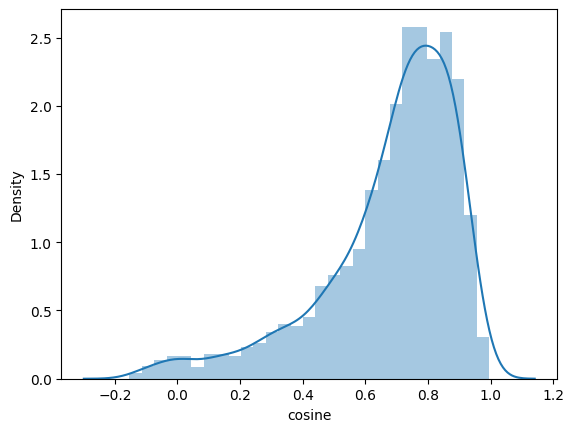

In [52]:
sns.distplot(df_gpt4o['cosine'], label="4o")
sns.distplot(df_gpt35['cosine'], label="3.5")
sns.distplot(df_gpt4omini['cosine'], label="4o-mini")

plt.legend()

# LLM as a Judge

In [26]:
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/evaluations-aqa.csv

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


--2025-07-30 07:42:23--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/evaluations-aqa.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50944 (50K) [text/plain]
Saving to: ‘evaluations-aqa.csv’

evaluations-aqa.csv 100%[===================>]  49.75K  --.-KB/s    in 0.001s  

2025-07-30 07:42:23 (59.4 MB/s) - ‘evaluations-aqa.csv’ saved [50944/50944]



In [28]:
!wget https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/evaluations-qa.csv

--2025-07-30 07:42:41--  https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/evaluations-qa.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


200 OK
Length: 44712 (44K) [text/plain]
Saving to: ‘evaluations-qa.csv’

evaluations-qa.csv  100%[===================>]  43.66K  --.-KB/s    in 0.001s  

2025-07-30 07:42:42 (56.5 MB/s) - ‘evaluations-qa.csv’ saved [44712/44712]



In [14]:
prompt1_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: {answer_orig}
Generated Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the original
answer and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

prompt2_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

In [17]:
df_sample = df_gpt4o_mini.sample(n=150, random_state=1)

In [18]:
samples = df_sample.to_dict(orient='records')

In [19]:
record = samples[0]
record

{'answer_llm': 'The syntax for using `precision_recall_fscore_support` in Python is as follows:\n\n```python\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n```',
 'answer_orig': 'Scikit-learn offers another way: precision_recall_fscore_support\nExample:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n(Gopakumar Gopinathan)',
 'document': '403bbdd8',
 'question': 'What is the syntax for using precision_recall_fscore_support in Python?',
 'course': 'machine-learning-zoomcamp'}

In [23]:
evaluations = []

# for record in tqdm(samples):
    prompt = prompt1_template.format(**record)
    evaluation = llm(prompt, model='gpt-4o-mini')
    evaluations.append(evaluation)

  0%|          | 0/150 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
json_evaluations = []

for i, str_eval in enumerate(evaluations):
    json_eval = json.loads(str_eval)
    json_evaluations.append(json_eval)

In [30]:
df_evaluations = pd.DataFrame(json_evaluations)

In [ ]:
df_evaluations.Relevance.value_counts()

In [ ]:
df_evaluations[df_evaluations.Relevance == 'NON_RELEVANT'] #.to_dict(orient='records')

In [ ]:
evaluations_2 = []

for record in tqdm(samples):
    prompt = prompt2_template.format(**record)
    evaluation = llm(prompt, model='gpt-4o-mini')
    evaluations_2.append(evaluation)

In [ ]:
json_evaluations_2 = []

for i, str_eval in enumerate(evaluations_2):
    json_eval = json.loads(str_eval)
    json_evaluations_2.append(json_eval)

In [ ]:
df_evaluations_2 = pd.DataFrame(json_evaluations_2)

In [ ]:
df_evaluations_2[df_evaluations_2.Relevance == 'NON_RELEVANT']